<a href="https://colab.research.google.com/github/Zeyd17/Medical_image_vessel_segmentation/blob/main/01_train_arcade_only_test_arcade_dca1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01 — Train Model 1: ARCADE-only, test ARCADE + DCA1

This notebook trains **ARCADE segmentation train only** using R50-ViT-B_16 ImageNet-21k weights.

Training schedule:

```text
warm-up: 10 epochs
full fine-tuning: 40 epochs
early stopping patience: 10
```

Device selection order is: **CUDA → MPS → CPU**. On A100, it should use CUDA.

In [3]:
# --------------------------
# Imports and setup
# --------------------------
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import os, sys, subprocess, random, json, math, time, shutil
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset, ConcatDataset

ROOT = Path('/content/drive/MyDrive/TransUNet_Compare')
DATA_DIR = ROOT / 'data'
OUTPUT_DIR = ROOT / 'output'
EXTERNAL_DIR = ROOT / 'external'
PRETRAIN_PATH = ROOT / 'R50+ViT-B_16.npz'

EXTERNAL_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('ROOT:', ROOT)
print('PRETRAIN exists:', PRETRAIN_PATH.exists(), PRETRAIN_PATH)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
ROOT: /content/drive/MyDrive/TransUNet_Compare
PRETRAIN exists: True /content/drive/MyDrive/TransUNet_Compare/R50+ViT-B_16.npz


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# --------------------------
# Install dependencies and clone TransUNet repo
# --------------------------
def pip_install(pkgs):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q'] + pkgs)

try:
    import ml_collections
except Exception:
    pip_install(['ml-collections'])

try:
    import cv2
except Exception:
    pip_install(['opencv-python'])

TRANSUNET_REPO = EXTERNAL_DIR / 'TransUNet'
if not TRANSUNET_REPO.exists():
    subprocess.check_call(['git', 'clone', 'https://github.com/Beckschen/TransUNet.git', str(TRANSUNET_REPO)])

sys.path.insert(0, str(TRANSUNET_REPO))
sys.path.insert(0, str(TRANSUNET_REPO / 'networks'))

from networks.vit_seg_modeling import VisionTransformer as ViT_seg
from networks.vit_seg_modeling import CONFIGS as CONFIGS_ViT

print('TransUNet repo:', TRANSUNET_REPO)

TransUNet repo: /content/drive/MyDrive/TransUNet_Compare/external/TransUNet


In [5]:
# --------------------------
# Configuration
# --------------------------
IMG_SIZE = 224
NUM_CLASSES = 2
BATCH_SIZE = 4

WARMUP_EPOCHS = 10
FINETUNE_EPOCHS = 40
MAX_EPOCHS = WARMUP_EPOCHS + FINETUNE_EPOCHS
EARLY_STOP_PATIENCE = 10

WARMUP_LR = 1e-4
FINETUNE_LR = 1e-5
WEIGHT_DECAY = 1e-4

THRESHOLD = 0.5
NUM_WORKERS = 2
SEED = 42
MONITOR_FRACTION = 0.10

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    try:
        torch.backends.cudnn.deterministic = False
        torch.backends.cudnn.benchmark = True
    except Exception:
        pass

def select_device():
    if torch.cuda.is_available():
        device = torch.device('cuda')
        print('Using CUDA GPU:', torch.cuda.get_device_name(0))
    elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
        device = torch.device('mps')
        print('Using Apple MPS')
    else:
        device = torch.device('cpu')
        print('Using CPU')
    return device

seed_everything(SEED)
DEVICE = select_device()

# For A100/Colab CUDA, AMP speeds up training.
USE_AMP = DEVICE.type == 'cuda'
print('USE_AMP:', USE_AMP)

Using CUDA GPU: NVIDIA L4
USE_AMP: True


In [6]:
# --------------------------
# Dataset and metrics
# --------------------------
class VesselFolderDataset(Dataset):
    def __init__(self, root_dir, img_size=224):
        self.root_dir = Path(root_dir)
        self.img_dir = self.root_dir / 'images'
        self.mask_dir = self.root_dir / 'masks'
        self.img_size = img_size

        self.image_paths = sorted([p for p in self.img_dir.glob('*') if p.suffix.lower() in ['.png', '.jpg', '.jpeg', '.pgm', '.tif', '.tiff', '.bmp']])
        self.items = []
        for img_path in self.image_paths:
            mask_path = self.mask_dir / img_path.name
            if mask_path.exists():
                self.items.append((img_path, mask_path))

        if len(self.items) == 0:
            raise RuntimeError(f'No paired images/masks found in {self.root_dir}')

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        img_path, mask_path = self.items[idx]

        img = Image.open(img_path).convert('L')
        mask = Image.open(mask_path).convert('L')

        original_size = img.size

        img = img.resize((self.img_size, self.img_size), resample=Image.BILINEAR)
        mask = mask.resize((self.img_size, self.img_size), resample=Image.NEAREST)

        img = np.array(img).astype(np.float32) / 255.0
        mask = (np.array(mask) > 0).astype(np.int64)

        # Per-image standardization helps angiograms with varying contrast.
        mean = img.mean()
        std = img.std()
        img = (img - mean) / (std + 1e-6)

        img_t = torch.from_numpy(img[None, ...]).float()
        mask_t = torch.from_numpy(mask).long()

        return {
            'image': img_t,
            'mask': mask_t,
            'name': img_path.name,
            'image_path': str(img_path),
            'mask_path': str(mask_path),
            'original_size': original_size,
        }

def split_train_monitor(dataset, monitor_fraction=0.10, seed=42):
    n = len(dataset)
    indices = list(range(n))
    rng = random.Random(seed)
    rng.shuffle(indices)
    n_monitor = max(1, int(round(n * monitor_fraction))) if n > 10 else max(1, n // 5)
    monitor_idx = indices[:n_monitor]
    train_idx = indices[n_monitor:]
    return Subset(dataset, train_idx), Subset(dataset, monitor_idx)

def foreground_dice_iou_from_logits(logits, masks, threshold=0.5, eps=1e-7):
    if logits.shape[-2:] != masks.shape[-2:]:
        logits = F.interpolate(logits, size=masks.shape[-2:], mode='bilinear', align_corners=False)

    if logits.shape[1] == 1:
        probs = torch.sigmoid(logits[:, 0])
    else:
        probs = torch.softmax(logits, dim=1)[:, 1]

    preds = probs >= threshold
    gts = masks > 0

    dices, ious = [], []
    for pred, gt in zip(preds, gts):
        pred = pred.bool()
        gt = gt.bool()
        inter = torch.logical_and(pred, gt).sum().float()
        pred_sum = pred.sum().float()
        gt_sum = gt.sum().float()
        union = torch.logical_or(pred, gt).sum().float()
        dice = (2 * inter + eps) / (pred_sum + gt_sum + eps)
        iou = (inter + eps) / (union + eps)
        dices.append(float(dice.detach().cpu()))
        ious.append(float(iou.detach().cpu()))
    return float(np.mean(dices)), float(np.mean(ious))

class DiceCELoss(nn.Module):
    def __init__(self, dice_weight=0.5, ce_weight=0.5, eps=1e-7):
        super().__init__()
        self.dice_weight = dice_weight
        self.ce_weight = ce_weight
        self.eps = eps
        self.ce = nn.CrossEntropyLoss()

    def forward(self, logits, target):
        if logits.shape[-2:] != target.shape[-2:]:
            logits = F.interpolate(logits, size=target.shape[-2:], mode='bilinear', align_corners=False)

        ce_loss = self.ce(logits, target)

        probs = torch.softmax(logits, dim=1)[:, 1]
        target_fg = (target > 0).float()
        inter = (probs * target_fg).sum(dim=(1,2))
        denom = probs.sum(dim=(1,2)) + target_fg.sum(dim=(1,2))
        dice_loss = 1.0 - ((2 * inter + self.eps) / (denom + self.eps)).mean()

        return self.ce_weight * ce_loss + self.dice_weight * dice_loss

def create_transunet_model():
    if not PRETRAIN_PATH.exists():
        raise FileNotFoundError(f'Missing pretrained weights: {PRETRAIN_PATH}')

    config_vit = CONFIGS_ViT['R50-ViT-B_16']
    config_vit.n_classes = NUM_CLASSES
    config_vit.n_skip = 3
    config_vit.patches.grid = (IMG_SIZE // 16, IMG_SIZE // 16)

    model = ViT_seg(config_vit, img_size=IMG_SIZE, num_classes=NUM_CLASSES)
    weights = np.load(str(PRETRAIN_PATH))
    model.load_from(weights=weights)
    return model

def set_warmup_trainable(model):
    # Freeze pretrained transformer/resnet pathway; train decoder + segmentation head.
    for name, param in model.named_parameters():
        param.requires_grad = False
        if name.startswith('decoder') or name.startswith('segmentation_head'):
            param.requires_grad = True

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    print(f'Warm-up trainable parameters: {trainable:,} / {total:,}')

def set_full_finetune_trainable(model):
    for param in model.parameters():
        param.requires_grad = True
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    print(f'Full fine-tuning trainable parameters: {trainable:,} / {total:,}')

def make_loader(dataset, batch_size, shuffle):
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=(DEVICE.type == 'cuda'),
        drop_last=False,
    )

In [7]:
# --------------------------
# Training and evaluation functions
# --------------------------
def run_one_epoch(model, loader, optimizer, scaler, criterion, train=True):
    model.train(train)
    losses, dices, ious = [], [], []

    for batch in loader:
        images = batch['image'].to(DEVICE, non_blocking=True)
        masks = batch['mask'].to(DEVICE, non_blocking=True)

        if train:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(train):
            with torch.cuda.amp.autocast(enabled=USE_AMP):
                logits = model(images)
                loss = criterion(logits, masks)

            if train:
                if USE_AMP:
                    scaler.scale(loss).backward()
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    loss.backward()
                    optimizer.step()

        dice, iou = foreground_dice_iou_from_logits(logits.detach(), masks, threshold=THRESHOLD)
        losses.append(float(loss.detach().cpu()))
        dices.append(dice)
        ious.append(iou)

    return {
        'loss': float(np.mean(losses)),
        'dice': float(np.mean(dices)),
        'iou': float(np.mean(ious)),
    }

def train_model(model, train_loader, monitor_loader, output_dir):
    output_dir = Path(output_dir)
    ckpt_dir = output_dir / 'checkpoints'
    ckpt_dir.mkdir(parents=True, exist_ok=True)

    criterion = DiceCELoss()
    history = []

    best_dice = -1
    best_epoch = -1
    no_improve = 0

    scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

    # Stage 1: warm-up
    set_warmup_trainable(model)
    optimizer = torch.optim.AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=WARMUP_LR,
        weight_decay=WEIGHT_DECAY,
    )

    for epoch in range(1, WARMUP_EPOCHS + 1):
        train_metrics = run_one_epoch(model, train_loader, optimizer, scaler, criterion, train=True)
        monitor_metrics = run_one_epoch(model, monitor_loader, optimizer, scaler, criterion, train=False)

        row = {'epoch': epoch, 'stage': 'warmup', **{f'train_{k}': v for k, v in train_metrics.items()}, **{f'monitor_{k}': v for k, v in monitor_metrics.items()}}
        history.append(row)
        print(row)

        if monitor_metrics['dice'] > best_dice:
            best_dice = monitor_metrics['dice']
            best_epoch = epoch
            torch.save({'model_state_dict': model.state_dict(), 'epoch': epoch, 'best_monitor_dice': best_dice, 'config': {
                'IMG_SIZE': IMG_SIZE, 'NUM_CLASSES': NUM_CLASSES, 'THRESHOLD': THRESHOLD
            }}, ckpt_dir / 'best_model.pth')

    # Stage 2: full fine-tuning
    set_full_finetune_trainable(model)
    optimizer = torch.optim.AdamW(model.parameters(), lr=FINETUNE_LR, weight_decay=WEIGHT_DECAY)

    for local_epoch in range(1, FINETUNE_EPOCHS + 1):
        epoch = WARMUP_EPOCHS + local_epoch
        train_metrics = run_one_epoch(model, train_loader, optimizer, scaler, criterion, train=True)
        monitor_metrics = run_one_epoch(model, monitor_loader, optimizer, scaler, criterion, train=False)

        row = {'epoch': epoch, 'stage': 'full_finetune', **{f'train_{k}': v for k, v in train_metrics.items()}, **{f'monitor_{k}': v for k, v in monitor_metrics.items()}}
        history.append(row)
        print(row)

        if monitor_metrics['dice'] > best_dice:
            best_dice = monitor_metrics['dice']
            best_epoch = epoch
            no_improve = 0
            torch.save({'model_state_dict': model.state_dict(), 'epoch': epoch, 'best_monitor_dice': best_dice, 'config': {
                'IMG_SIZE': IMG_SIZE, 'NUM_CLASSES': NUM_CLASSES, 'THRESHOLD': THRESHOLD
            }}, ckpt_dir / 'best_model.pth')
            print(f'  Saved new best checkpoint: epoch={epoch}, dice={best_dice:.4f}')
        else:
            no_improve += 1
            print(f'  No improvement for {no_improve}/{EARLY_STOP_PATIENCE} epochs')

        if no_improve >= EARLY_STOP_PATIENCE:
            print(f'Early stopping at epoch {epoch}. Best epoch={best_epoch}, best monitor Dice={best_dice:.4f}')
            break

    hist_df = pd.DataFrame(history)
    hist_df.to_csv(output_dir / 'training_history.csv', index=False)

    # Curves
    plt.figure(figsize=(7,5))
    plt.plot(hist_df['epoch'], hist_df['train_loss'], label='train_loss')
    plt.plot(hist_df['epoch'], hist_df['monitor_loss'], label='monitor_loss')
    plt.axvline(WARMUP_EPOCHS, linestyle='--', label='warmup end')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Loss curve')
    plt.tight_layout()
    plt.savefig(output_dir / 'loss_curve.png', dpi=160)
    plt.show()

    plt.figure(figsize=(7,5))
    plt.plot(hist_df['epoch'], hist_df['train_dice'], label='train_dice')
    plt.plot(hist_df['epoch'], hist_df['monitor_dice'], label='monitor_dice')
    plt.plot(hist_df['epoch'], hist_df['train_iou'], label='train_iou')
    plt.plot(hist_df['epoch'], hist_df['monitor_iou'], label='monitor_iou')
    plt.axvline(WARMUP_EPOCHS, linestyle='--', label='warmup end')
    plt.xlabel('Epoch')
    plt.ylabel('Score')
    plt.legend()
    plt.title('Dice/IoU curve')
    plt.tight_layout()
    plt.savefig(output_dir / 'dice_iou_curve.png', dpi=160)
    plt.show()

    return hist_df

def numpy_metrics(pred, gt, eps=1e-7):
    pred = pred.astype(bool)
    gt = gt.astype(bool)
    inter = np.logical_and(pred, gt).sum()
    union = np.logical_or(pred, gt).sum()
    dice = (2 * inter + eps) / (pred.sum() + gt.sum() + eps)
    iou = (inter + eps) / (union + eps)
    return float(dice), float(iou), int(inter), int(union), int(pred.sum()), int(gt.sum())

def make_eval_overlay(img, gt, pred):
    img_u8 = img.astype(np.uint8)
    rgb = np.stack([img_u8, img_u8, img_u8], axis=-1)
    gt_b = gt.astype(bool)
    pred_b = pred.astype(bool)
    tp = gt_b & pred_b
    fp = (~gt_b) & pred_b
    fn = gt_b & (~pred_b)
    rgb[tp] = [0, 255, 0]       # green: overlap
    rgb[fp] = [255, 0, 255]     # magenta: false positive
    rgb[fn] = [255, 255, 0]     # yellow: missed GT
    return rgb

def save_eval_panel(img, gt, pred, dice, iou, title, out_path):
    overlay = make_eval_overlay(img, gt, pred)
    fig, axes = plt.subplots(1, 4, figsize=(16,4))
    axes[0].imshow(img, cmap='gray'); axes[0].set_title('Input'); axes[0].axis('off')
    axes[1].imshow(gt, cmap='gray'); axes[1].set_title('Ground truth'); axes[1].axis('off')
    axes[2].imshow(pred, cmap='gray'); axes[2].set_title('Generated mask'); axes[2].axis('off')
    axes[3].imshow(overlay); axes[3].set_title(f'Overlap\nDice={dice:.3f}, IoU={iou:.3f}'); axes[3].axis('off')
    fig.suptitle(title)
    plt.tight_layout()
    out_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_path, dpi=160)
    plt.close(fig)

def dice_band_name(dice):
    lo = int(np.floor(dice * 10)) / 10
    if dice >= 1.0:
        lo = 0.9
    hi = lo + 0.1
    return f'dice_{lo:.1f}_{hi:.1f}'.replace('.', 'p')

@torch.no_grad()
def evaluate_and_save(model, dataset_dir, output_dir, dataset_label):
    output_dir = Path(output_dir) / f'evaluation_{dataset_label}'
    pred_dir = output_dir / 'test_pred_masks'
    prob_dir = output_dir / 'test_probability_maps'
    img_out_dir = output_dir / 'test_images' / 'all'
    band_dir = output_dir / 'test_images' / 'dice_bands'

    for p in [pred_dir, prob_dir, img_out_dir, band_dir]:
        p.mkdir(parents=True, exist_ok=True)

    ds = VesselFolderDataset(dataset_dir, img_size=IMG_SIZE)
    loader = make_loader(ds, batch_size=1, shuffle=False)

    rows = []
    model.eval()

    for batch in loader:
        images = batch['image'].to(DEVICE)
        masks = batch['mask'].to(DEVICE)
        name = batch['name'][0]

        logits = model(images)
        if logits.shape[-2:] != masks.shape[-2:]:
            logits = F.interpolate(logits, size=masks.shape[-2:], mode='bilinear', align_corners=False)

        probs = torch.softmax(logits, dim=1)[:, 1][0].detach().cpu().numpy()
        pred_small = probs >= THRESHOLD

        # Save at original canonical 224 size for fair evaluation.
        gt_small = masks[0].detach().cpu().numpy() > 0

        # Also load original canonical image/mask from disk, which is not necessarily 224.
        img_path = Path(batch['image_path'][0])
        mask_path = Path(batch['mask_path'][0])
        img_orig = np.array(Image.open(img_path).convert('L'))
        gt_orig = np.array(Image.open(mask_path).convert('L')) > 0

        # Resize pred to original image size for saved visualization.
        pred_orig = np.array(Image.fromarray((pred_small.astype(np.uint8) * 255)).resize((img_orig.shape[1], img_orig.shape[0]), resample=Image.NEAREST)) > 0
        prob_orig = np.array(Image.fromarray((probs * 255).astype(np.uint8)).resize((img_orig.shape[1], img_orig.shape[0]), resample=Image.BILINEAR))

        dice, iou, inter, union, pred_px, gt_px = numpy_metrics(pred_orig, gt_orig)

        pred_u8 = pred_orig.astype(np.uint8) * 255
        Image.fromarray(pred_u8).save(pred_dir / name)
        Image.fromarray(prob_orig.astype(np.uint8)).save(prob_dir / name)

        panel_path = img_out_dir / name
        save_eval_panel(img_orig, gt_orig.astype(np.uint8) * 255, pred_u8, dice, iou, f'{dataset_label} | {name}', panel_path)

        band = dice_band_name(dice)
        band_path = band_dir / band / name
        save_eval_panel(img_orig, gt_orig.astype(np.uint8) * 255, pred_u8, dice, iou, f'{dataset_label} | {name}', band_path)

        rows.append({
            'dataset': dataset_label,
            'name': name,
            'dice': dice,
            'iou': iou,
            'intersection_pixels': inter,
            'union_pixels': union,
            'pred_pixels': pred_px,
            'gt_pixels': gt_px,
            'pred_area_ratio': pred_px / pred_orig.size,
            'gt_area_ratio': gt_px / gt_orig.size,
            'panel_path': str(panel_path),
            'pred_mask_path': str(pred_dir / name),
            'probability_map_path': str(prob_dir / name),
        })

    df = pd.DataFrame(rows)
    df.to_csv(output_dir / 'test_per_image_metrics.csv', index=False)

    summary = {
        'dataset': dataset_label,
        'num_images': int(len(df)),
        'mean_dice': float(df['dice'].mean()),
        'std_dice': float(df['dice'].std(ddof=0)),
        'mean_iou': float(df['iou'].mean()),
        'std_iou': float(df['iou'].std(ddof=0)),
        'median_dice': float(df['dice'].median()),
        'median_iou': float(df['iou'].median()),
    }
    with open(output_dir / 'test_summary_metrics.json', 'w') as f:
        json.dump(summary, f, indent=2)

    band_summary = df.assign(dice_band=df['dice'].apply(dice_band_name)).groupby('dice_band').agg(
        num_images=('name', 'count'),
        mean_dice=('dice', 'mean'),
        mean_iou=('iou', 'mean'),
    ).reset_index()
    band_summary.to_csv(output_dir / 'test_dice_band_summary.csv', index=False)

    print('Evaluation summary:', summary)
    return df, summary

In [8]:
# --------------------------
# Dataset setup: Model 1 = ARCADE train only
# --------------------------
MODEL_OUTPUT_DIR = OUTPUT_DIR / 'model_01_arcade_train'
MODEL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

arcade_train_full = VesselFolderDataset(DATA_DIR / 'dataARCADE' / 'train', img_size=IMG_SIZE)
train_ds, monitor_ds = split_train_monitor(arcade_train_full, monitor_fraction=MONITOR_FRACTION, seed=SEED)

print('ARCADE full train:', len(arcade_train_full))
print('Internal train subset:', len(train_ds))
print('Internal monitor subset:', len(monitor_ds))

train_loader = make_loader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
monitor_loader = make_loader(monitor_ds, batch_size=BATCH_SIZE, shuffle=False)

ARCADE full train: 1200
Internal train subset: 1080
Internal monitor subset: 120


/tmp/ipykernel_315/3882190934.py:52: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)


Warm-up trainable parameters: 7,387,490 / 105,276,066


/tmp/ipykernel_315/3882190934.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
/tmp/ipykernel_315/3882190934.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
/tmp/ipykernel_315/3882190934.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
/tmp/ipykernel_315/3882190934.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
/tmp/ipykernel_315/3882190934.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  wi

{'epoch': 1, 'stage': 'warmup', 'train_loss': 0.49546504925798485, 'train_dice': 0.5593185447225416, 'train_iou': 0.4078648092552882, 'monitor_loss': 0.330413152774175, 'monitor_dice': 0.671322092662255, 'monitor_iou': 0.5193181048457821}
{'epoch': 2, 'stage': 'warmup', 'train_loss': 0.23375325694128318, 'train_dice': 0.7202855562584267, 'train_iou': 0.5718046095291222, 'monitor_loss': 0.19244183748960494, 'monitor_dice': 0.741542483617862, 'monitor_iou': 0.60043436139822}
{'epoch': 3, 'stage': 'warmup', 'train_loss': 0.17872740838814666, 'train_dice': 0.7494684021644018, 'train_iou': 0.6076891326724931, 'monitor_loss': 0.18580820659796396, 'monitor_dice': 0.7222338492671648, 'monitor_iou': 0.5787342509254814}
{'epoch': 4, 'stage': 'warmup', 'train_loss': 0.1546524106628365, 'train_dice': 0.7757033174236615, 'train_iou': 0.6409492752066365, 'monitor_loss': 0.1581101360420386, 'monitor_dice': 0.7673298565049966, 'monitor_iou': 0.6322077391048272}
{'epoch': 5, 'stage': 'warmup', 'train_l

/tmp/ipykernel_315/3882190934.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
/tmp/ipykernel_315/3882190934.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


{'epoch': 30, 'stage': 'full_finetune', 'train_loss': 0.05720645100982101, 'train_dice': 0.9143918227818277, 'train_iou': 0.843149952756034, 'monitor_loss': 0.14247332140803337, 'monitor_dice': 0.7929678748051325, 'monitor_iou': 0.6676676171521346}
  No improvement for 1/10 epochs
{'epoch': 31, 'stage': 'full_finetune', 'train_loss': 0.05647264320265364, 'train_dice': 0.9152179566246492, 'train_iou': 0.8445175930305764, 'monitor_loss': 0.14337299888332686, 'monitor_dice': 0.7918279565870762, 'monitor_iou': 0.6662191297858954}
  No improvement for 2/10 epochs
{'epoch': 32, 'stage': 'full_finetune', 'train_loss': 0.05622038660501992, 'train_dice': 0.9156114439169566, 'train_iou': 0.845217597981294, 'monitor_loss': 0.1422129732867082, 'monitor_dice': 0.7947788623472055, 'monitor_iou': 0.669863204161326}
  No improvement for 3/10 epochs
{'epoch': 33, 'stage': 'full_finetune', 'train_loss': 0.055077435365981524, 'train_dice': 0.9173294490686169, 'train_iou': 0.848096337693709, 'monitor_loss

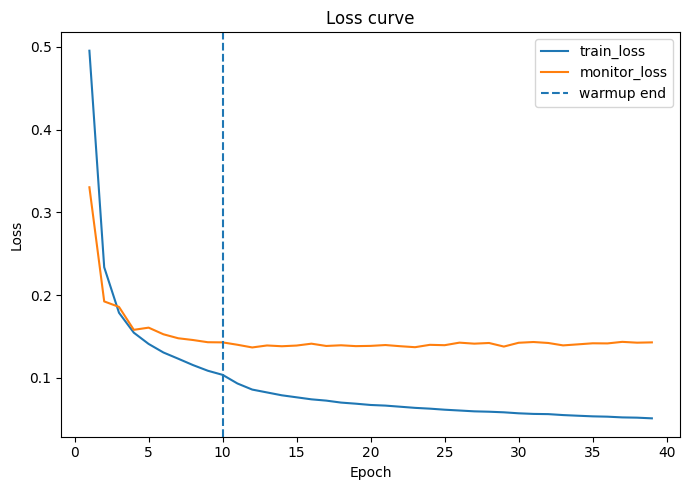

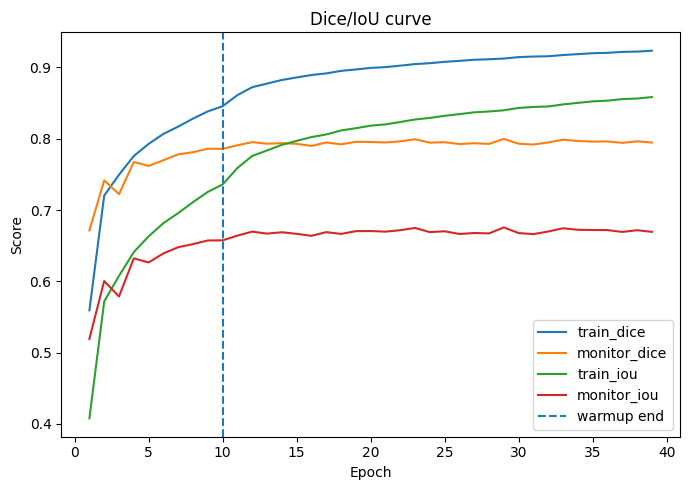

Training complete.
Best checkpoint: /content/drive/MyDrive/TransUNet_Compare/output/model_01_arcade_train/checkpoints/best_model.pth


In [9]:
# --------------------------
# Create model and train
# --------------------------
model = create_transunet_model().to(DEVICE)
history_df = train_model(model, train_loader, monitor_loader, MODEL_OUTPUT_DIR)

print('Training complete.')
print('Best checkpoint:', MODEL_OUTPUT_DIR / 'checkpoints' / 'best_model.pth')

In [10]:
# --------------------------
# Load best checkpoint and test on ARCADE test + DCA1 test
# --------------------------
best_ckpt = MODEL_OUTPUT_DIR / 'checkpoints' / 'best_model.pth'
if not best_ckpt.exists():
    raise FileNotFoundError(f'Missing checkpoint: {best_ckpt}')

checkpoint = torch.load(best_ckpt, map_location=DEVICE)
model = create_transunet_model().to(DEVICE)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print('Loaded best checkpoint from epoch:', checkpoint.get('epoch'))
print('Best monitor Dice:', checkpoint.get('best_monitor_dice'))

arcade_df, arcade_summary = evaluate_and_save(
    model,
    DATA_DIR / 'dataARCADE' / 'test',
    MODEL_OUTPUT_DIR,
    dataset_label='ARCADE_test'
)

dca1_df, dca1_summary = evaluate_and_save(
    model,
    DATA_DIR / 'dataDCA1' / 'test',
    MODEL_OUTPUT_DIR,
    dataset_label='DCA1_test'
)

combined = pd.concat([arcade_df, dca1_df], ignore_index=True)
combined.to_csv(MODEL_OUTPUT_DIR / 'combined_test_per_image_metrics.csv', index=False)

print('Saved all outputs to:', MODEL_OUTPUT_DIR)
display(pd.DataFrame([arcade_summary, dca1_summary]))

Loaded best checkpoint from epoch: 29
Best monitor Dice: 0.7996797723074754
Evaluation summary: {'dataset': 'ARCADE_test', 'num_images': 300, 'mean_dice': 0.7907808739805756, 'std_dice': 0.08289280798989515, 'mean_iou': 0.6610731449951538, 'std_iou': 0.10448230398533306, 'median_dice': 0.8084412568018186, 'median_iou': 0.6784745158807255}
Evaluation summary: {'dataset': 'DCA1_test', 'num_images': 27, 'mean_dice': 0.667241421156172, 'std_dice': 0.07995660673984102, 'mean_iou': 0.5056719954156768, 'std_iou': 0.08404776931618352, 'median_dice': 0.686185105194095, 'median_iou': 0.5222844617690905}
Saved all outputs to: /content/drive/MyDrive/TransUNet_Compare/output/model_01_arcade_train


,dataset,num_images,mean_dice,std_dice,mean_iou,std_iou,median_dice,median_iou
0,ARCADE_test,300,0.790781,0.082893,0.661073,0.104482,0.808441,0.678475
1,DCA1_test,27,0.667241,0.079957,0.505672,0.084048,0.686185,0.522284
